In [1]:
import numpy as np
import pandas as pd
import json
from pathlib import Path
from datetime import datetime

In [2]:
path = Path.cwd()
path.parent

WindowsPath('e:/Code/MCSR/src')

In [3]:
DATA_DIR = Path("../../data")
MATCHES_DIR = DATA_DIR / "raw" / "matches"
# for file_path in MATCHES_DIR.glob("*.json"):
#     print(file_path)

Feature: 
match_id, season, date, seed_type, bastion_type, player_uuid (both players), player_names,
winner_uuid, time, elo (both players, before matches), forfeied, elo_change_a 

In [4]:
all_matches_data = []

print(MATCHES_DIR.glob("*.json"))
for file_path in MATCHES_DIR.glob("*.json"):
    print(file_path)
    with open(file_path, "r") as file:
        matches = json.load(file)

    for match in matches:
        if not match.get("seed"):
            continue

        players = match.get("players")
        player_a, player_b = players[0], players[1]
        player_a_uuid, player_a_nickname = player_a.get("uuid"), player_a.get("nickname")
        player_b_uuid, player_b_nickname = player_b.get("uuid"), player_b.get("nickname")

        #Map the elo changes on the correct player(fixed)
        changes_list = match.get("changes",[])
        changes_a = None
        changes_b = None

        for change_dict in changes_list:
            if change_dict["uuid"] == player_a_uuid:
                changes_a = change_dict

            elif change_dict["uuid"] == player_b_uuid:
                changes_b = change_dict

        if not changes_a.get("eloRate") or not changes_a.get("change"):
            continue
        if not changes_b.get("eloRate") or not changes_b.get("change"):
            continue
        match_id = match.get("id") #match_id
        season = match.get("season") #season
        date = match.get("date") #date (unix format)
        seed_type = match.get("seedType") #seed_type (overworld)
        bastion_type = match.get("bastionType") #basion_type (nether)

        time = round(match.get("result").get("time") / 1000, 3) #time (in seconds)

        #Calculate elo pre match
        elo_a_before = changes_a.get("eloRate") - changes_a.get("change")
        elo_b_before = changes_b.get("eloRate") - changes_b.get("change") #player a lost 10 -> player b gained 10
        has_player_forfeited = str(match.get("forfeited")) #True if player_a or b forfeited mid game
        winner_uuid = match.get("result").get("uuid") #target label
        all_matches_data.append({
            "match_id": match_id,
            "season": season,
            "date": date,
            "seed_type": seed_type,
            "bastion_type": bastion_type,
            "player_a_uuid": player_a_uuid,
            "player_b_uuid": player_b_uuid,
            "player_a_nickname": player_a_nickname,
            "player_b_nickname": player_b_nickname,
            "time": time,
            "elo_a_before": elo_a_before,
            "elo_b_before": elo_b_before,
            "has_player_forfeited": has_player_forfeited,
            "winner_uuid": winner_uuid})

df = pd.DataFrame(all_matches_data)
df = df.drop_duplicates(subset=["match_id"])
df = df.sort_values("date", ascending=True).reset_index(drop=True)

df.to_csv(DATA_DIR / "processed" / "all_matches.csv")








<generator object Path.glob at 0x000002248FF3A240>
..\..\data\raw\matches\Aquacorde.json
..\..\data\raw\matches\BeefSalad.json
..\..\data\raw\matches\bing_pigs.json
..\..\data\raw\matches\BlazeMind.json
..\..\data\raw\matches\doogile.json
..\..\data\raw\matches\edcr.json
..\..\data\raw\matches\Feinberg.json
..\..\data\raw\matches\hackingnoises.json
..\..\data\raw\matches\HDMICables.json
..\..\data\raw\matches\Infume.json
..\..\data\raw\matches\lowk3y_.json
..\..\data\raw\matches\nahhann.json
..\..\data\raw\matches\Pinne.json
..\..\data\raw\matches\silverrruns.json
..\..\data\raw\matches\steez.json
..\..\data\raw\matches\steezFemboy.json


In [5]:
df = pd.read_csv(DATA_DIR / "processed" / "all_matches.csv")
df['datetime'] = pd.to_datetime(df['date'], unit='s')
df = df.sort_values("date").reset_index(drop=True)

# Clear forfeited matches
df_clean = df[df['has_player_forfeited'] != True].copy()
print(f"Clean matches remaining: {len(df_clean)}")
df_clean.head()

Clean matches remaining: 9676


,Unnamed: 0,match_id,season,date,seed_type,bastion_type,player_a_uuid,player_b_uuid,player_a_nickname,player_b_nickname,time,elo_a_before,elo_b_before,has_player_forfeited,winner_uuid,datetime
0,0,2803910,9,1755742042,RUINED_PORTAL,STABLES,185b039b70284aa9a98850db4ba88e0d,2ef2bfed3d084649b56290328970ace9,ElegantRobin,nahhann,562.592,1481,1651,False,185b039b70284aa9a98850db4ba88e0d,2025-08-21 02:07:22
1,1,2803960,9,1755744563,DESERT_TEMPLE,HOUSING,253b53d832ab4bafb5ee0308d5164ccf,5ee577fdc1af45d3a6fb3e086cc293fb,Aquacorde,Ranik_,581.443,1574,1636,False,253b53d832ab4bafb5ee0308d5164ccf,2025-08-21 02:49:23
3,3,2804294,9,1755752305,VILLAGE,TREASURE,253b53d832ab4bafb5ee0308d5164ccf,939ddf85303441de901d60bfa4109318,Aquacorde,thecamo6,714.868,1582,1664,False,253b53d832ab4bafb5ee0308d5164ccf,2025-08-21 04:58:25
4,4,2804359,9,1755753018,SHIPWRECK,TREASURE,2ef2bfed3d084649b56290328970ace9,253b53d832ab4bafb5ee0308d5164ccf,nahhann,Aquacorde,579.030,1630,1643,False,2ef2bfed3d084649b56290328970ace9,2025-08-21 05:10:18
6,6,2804458,9,1755753995,VILLAGE,BRIDGE,3c8757790ab0400b8b9e3936e0dd535b,2e4fbe60568549f7a6666e1ced1ae385,doogile,R3nR,502.200,1751,1350,False,3c8757790ab0400b8b9e3936e0dd535b,2025-08-21 05:26:35


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

count    9676.000000
mean      591.034597
std        92.955566
min       347.271000
25%       527.948000
50%       577.505500
75%       635.624250
max      1810.319000
Name: time, dtype: float64


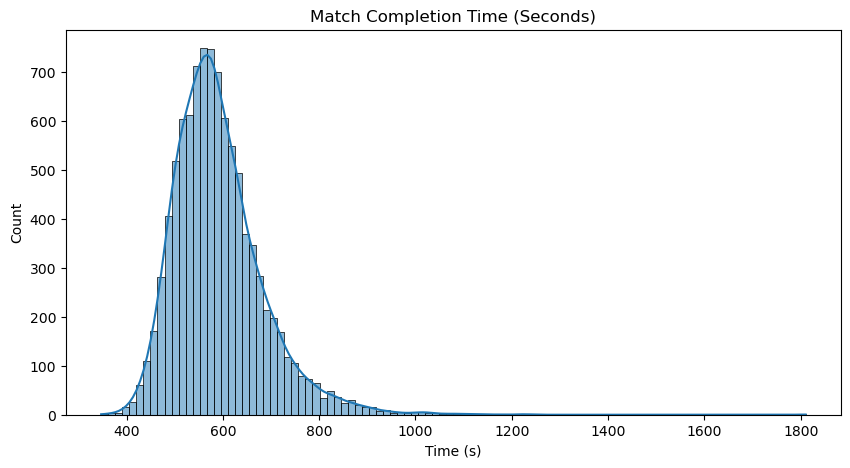

In [7]:
print(df_clean['time'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(df_clean['time'], bins=100, kde=True)
plt.title("Match Completion Time (Seconds)")
plt.xlabel("Time (s)")
plt.ylabel("Count")
plt.show()

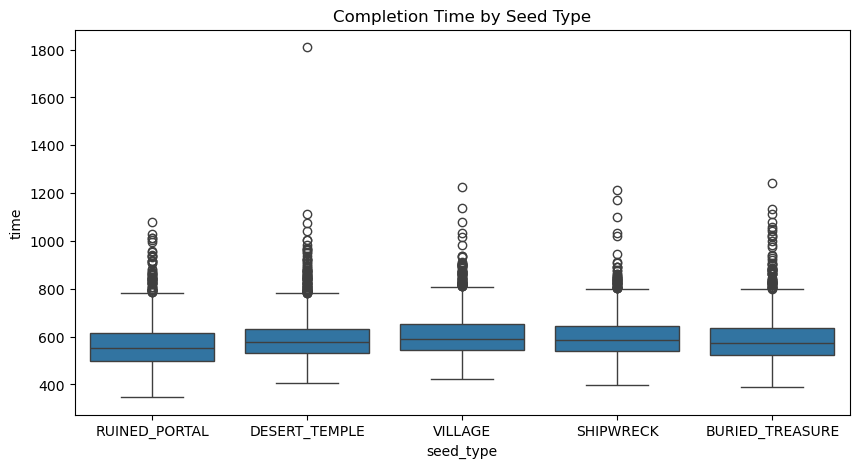

In [8]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x='seed_type', y='time')
plt.title("Completion Time by Seed Type")
plt.show()

In [9]:
df_clean['a_is_favored'] = df_clean['elo_a_before'] > df_clean['elo_b_before']
df_clean['a_won'] = df_clean['winner_uuid'] == df_clean['player_a_uuid']
baseline_accuracy = (df_clean['a_is_favored'] == df_clean['a_won']).mean()

print(f"Baseline Accuracy (Higher Elo Wins): {baseline_accuracy * 100:.2f}%")

Baseline Accuracy (Higher Elo Wins): 53.50%


sdfsgsd